# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

# **1. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

# **2. Memuat Dataset**

In [2]:
# Load data

### MULAI CODE ###

url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

### SELESAI CODE ###

In [3]:
# Tampilkan 5 baris pertama dengan function head.

### MULAI CODE ###

df.head()

### SELESAI CODE ###

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.

### MULAI CODE ###

df.info()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe

### MULAI CODE ###

df.describe()

### SELESAI CODE ###

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


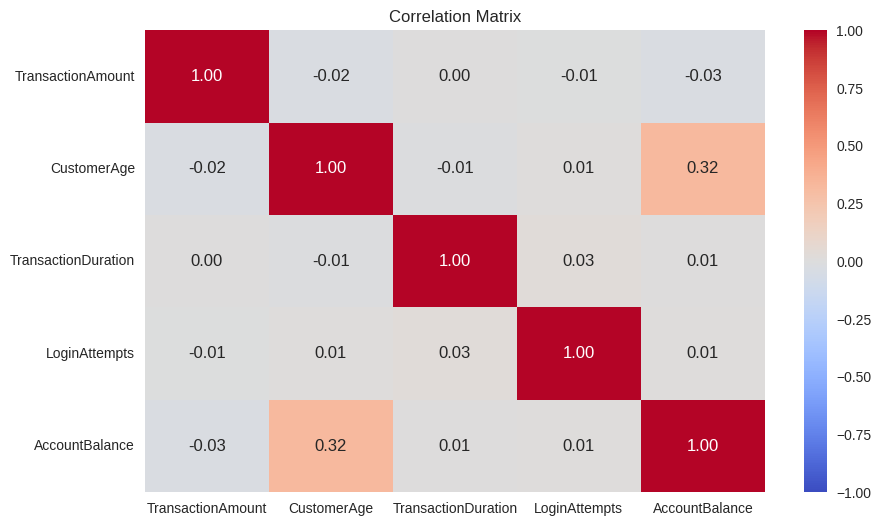

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

### MULAI CODE ###

# Hitung matriks korelasi
correlation = df[numerical_cols].corr()

# Buat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
               annot=True,
               cmap='coolwarm',
               fmt=".2f",
               vmin=-1,
               vmax=1)
plt.title('Correlation Matrix')
plt.show()

### SELESAI CODE ###

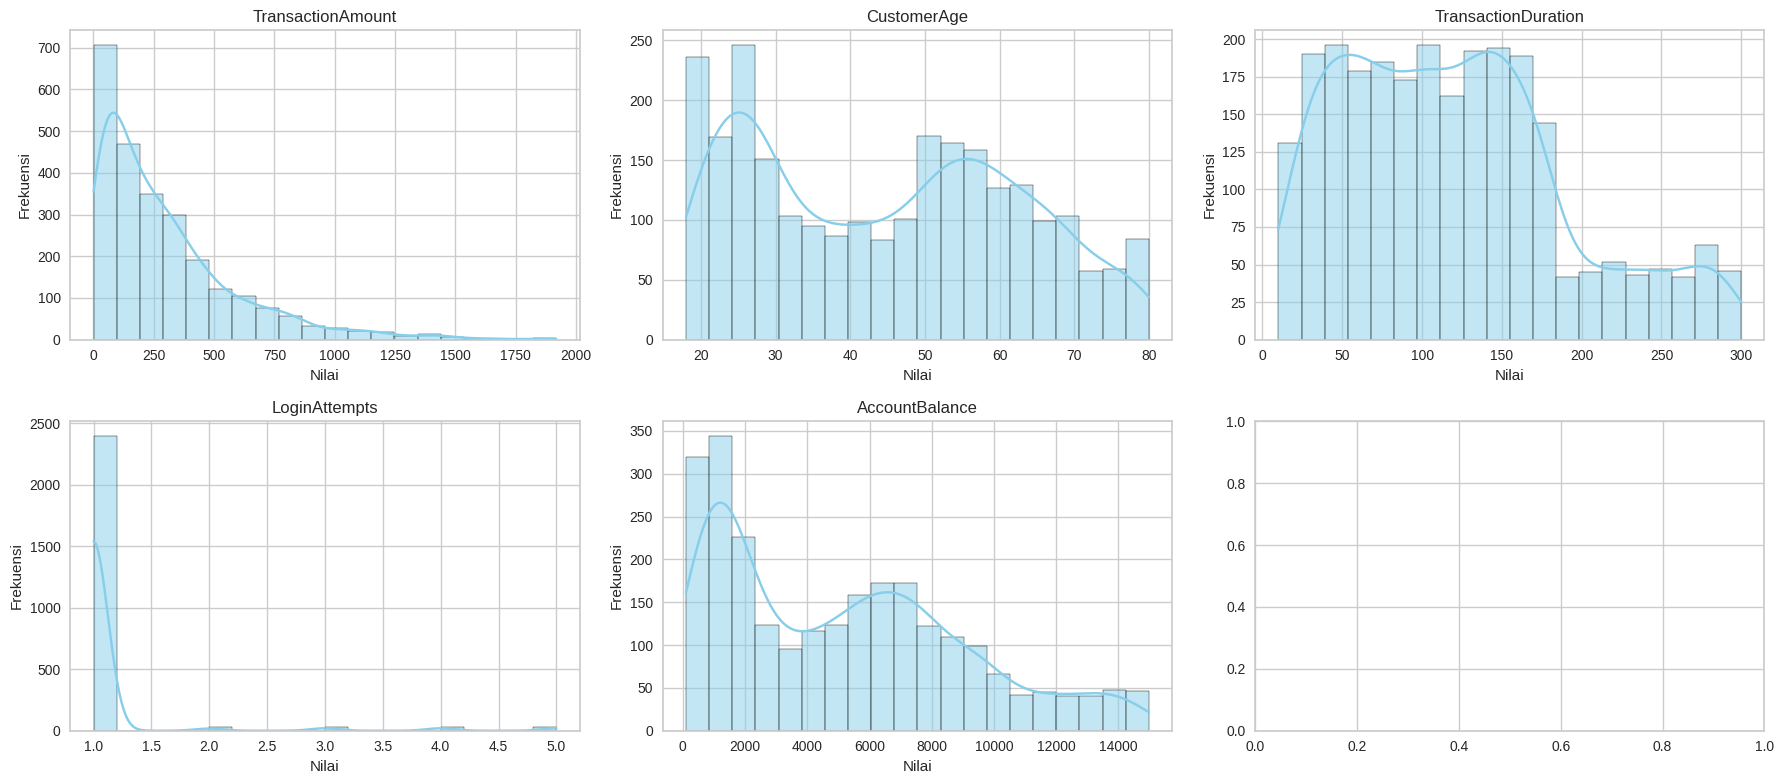

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    ### MULAI CODE ###

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

    ### SELESAI CODE ###

plt.tight_layout()
plt.show()

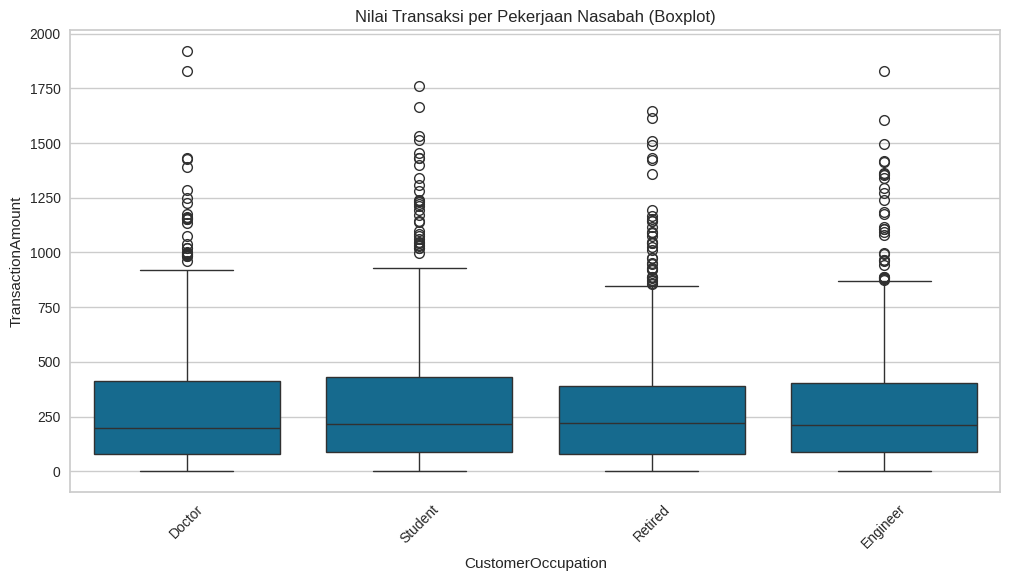

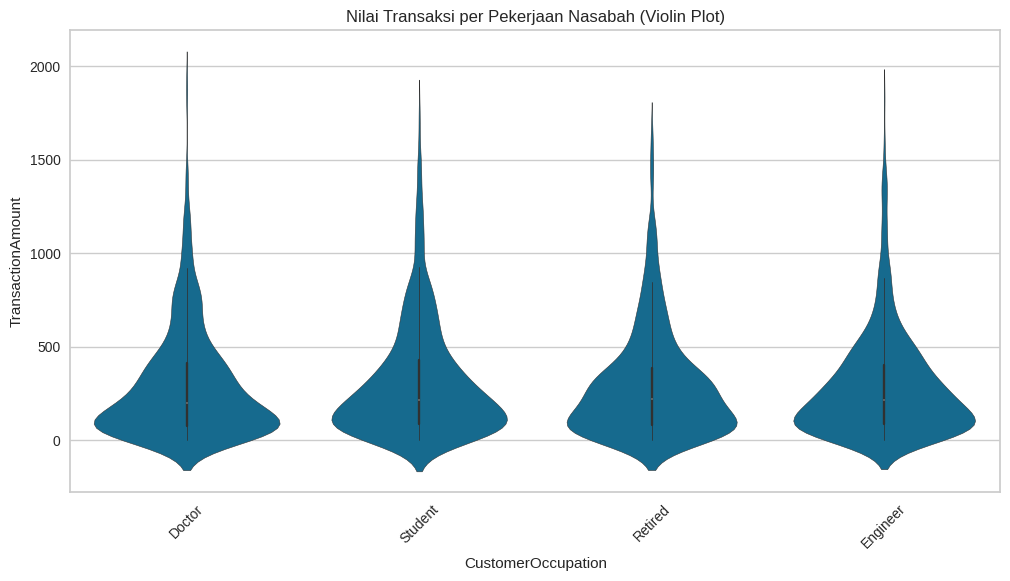

In [ ]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)

### MULAI CODE ###

plt.figure(figsize=(12, 6))

# Buat visualisasi boxplot untuk melihat sebaran 'TransactionAmount' (y) berdasarkan 'CustomerOccupation' (x)
sns.boxplot(x='CustomerOccupation', y='TransactionAmount', data=df)

plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")

# Putar label sumbu-x agar tidak tumpang tindih
plt.xticks(rotation=45)

plt.show()

### SELESAI CODE ###

#visualisasi, misalnya 'violinplot' (sns.violinplot) dengan parameter yang sama.

plt.figure(figsize=(12, 6))
sns.violinplot(x='CustomerOccupation', y='TransactionAmount', data=df)
plt.title("Nilai Transaksi per Pekerjaan Nasabah (Violin Plot)")
plt.xticks(rotation=45)
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**


In [9]:
# Mengecek dataset menggunakan isnull().sum()

### MULAI CODE ###

df.isnull().sum()

### SELESAI CODE ###

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [10]:
# Mengecek dataset menggunakan duplicated().sum()

### MULAI CODE ###

df.duplicated().sum()

### SELESAI CODE ###

np.int64(21)

In [11]:
# Menangani data yang hilang.

### MULAI CODE ###

# Panggil fungsi untuk menghapus baris yang hilang dan pastikan agar perubahan disimpan kembali ke 'df'
df.dropna(inplace=True)

# Cek kembali dataset menggunakan isnull().sum()
df.isnull().sum()

### SELESAI CODE ###

,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [12]:
# Menghapus data duplikat.

### MULAI CODE ###

# Panggil fungsi untuk menghapus baris duplikat dan pastikan agar perubahan disimpan kembali ke 'df'
df.drop_duplicates(inplace=True)

# Cek kembali dataset menggunakan duplicated().sum()
df.duplicated().sum()

### SELESAI CODE ###

np.int64(0)

In [ ]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address

### MULAI CODE ###

# Buat list comprehension untuk memfilter nama kolom.

cols_to_drop = [col for col in df.columns if
                'id' in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower()]

# Gunakan fungsi .drop() untuk menghapus kolom-kolom yang ada di 'cols_to_drop'.
df = df.drop(columns=cols_to_drop)

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68


In [ ]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Menggunakan function head setelah melalukan encoding.

### MULAI CODE ###

# Pilih semua kolom yang bertipe 'object' (kategorikal)
categorical_cols = list(df.select_dtypes(include=['object']).columns)

encoders = {}

# Loop melalui setiap kolom kategorikal
for column in categorical_cols:
    # Buat (instantiate) objek LabelEncoder
    label_encoder = LabelEncoder()

    # Terapkan (fit) encoder ke data dan sekaligus ubah (transform) data tersebut
    df[column] = label_encoder.fit_transform(df[column])

    # Simpan encoder
    encoders[column] = label_encoder

# Tampilkan 5 baris pertama untuk memverifikasi hasil encoding
df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


In [ ]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.

### MULAI CODE ###

df.columns.tolist()

### SELESAI CODE ###

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [16]:
# Melakukan Handling Outlier Data menggunakan metode drop.

for col in numerical_cols:

    ### MULAI CODE ###

    # Hitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Hitung Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Tentukan batas bawah (lower bound) dan batas atas (upper bound)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame: Simpan hanya baris di mana nilai 'df[col]' berada DI ANTARA (inklusif) batas bawah dan batas atas.
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    ### SELESAI CODE ###

# Tampilkan statistik deskriptif setelah outlier dihapus
df.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.0,1945.000000
mean,256.838278,0.771722,21.299743,0.977378,44.693059,1.503342,119.225193,1.0,5100.811913
std,218.370197,0.419830,12.329250,0.804119,17.743453,1.135888,70.600647,0.0,3907.153333
min,0.260000,0.000000,0.000000,0.000000,18.000000,0.000000,10.000000,1.0,102.200000
25%,78.920000,1.000000,11.000000,0.000000,27.000000,0.000000,63.000000,1.0,1488.650000
50%,199.700000,1.000000,21.000000,1.000000,45.000000,1.000000,111.000000,1.0,4693.600000
75%,374.500000,1.000000,32.000000,2.000000,59.000000,3.000000,162.000000,1.0,7659.990000
max,903.190000,1.000000,42.000000,2.000000,80.000000,3.000000,300.000000,1.0,14977.990000


In [ ]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
# Menggunakan function head setelah melalukan scaling.

### MULAI CODE ###

# Buat (instantiate) StandardScaler
scaler = StandardScaler()

# Terapkan (fit) scaler ke data dan sekaligus ubah (transform) data tersebut
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasil scaling
df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726


In [ ]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Encode hasil binning tersebut menggunakan LabelEncoder.

### MULAI CODE ###

# Tentukan kolom numerik
col_to_bin = 'CustomerAge'  # (Isi dengan 'CustomerAge' atau kolom numerik lain)

# Tentukan nama untuk kolom kategori baru
new_col_name = 'AgeGroup'

# Tentukan label untuk 3 grup 
# Mulai dari rendah --> sedang --> tinggi
bin_labels = ['Young', 'Adult', 'Senior']

# Gunakan 'pd.qcut' untuk membagi data menjadi 3 kelompok
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

# Lakukan Label Encoding pada kolom baru ini agar menjadi numerik
label_encoder = LabelEncoder()
df[new_col_name] = label_encoder.fit_transform(df[new_col_name])

# Simpan encoder dan tambahkan nama kolom baru ke 'categorical_cols'
encoders[new_col_name] = label_encoder
categorical_cols.extend([new_col_name])

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,1
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,1
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,2
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,2
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,2


# **4. Membangun Model Clustering**

In [ ]:
# Describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Mengubah nama DataFrame yang akan dilatih.

### MULAI CODE ###

# Buat salinan (copy) dari 'df' ke variabel 'df_used'
df_used = df.copy()

# Tampilkan ringkasan statistik dari DataFrame 'df'
df_used.describe()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup
count,1.945000e+03,1945.000000,1945.000000,1945.000000,1.945000e+03,1945.000000,1.945000e+03,1945.0,1.945000e+03,1945.000000
mean,-8.402305e-17,0.771722,21.299743,0.977378,-1.269479e-16,1.503342,2.557223e-17,0.0,-6.027740e-17,1.015424
std,1.000257e+00,0.419830,12.329250,0.804119,1.000257e+00,1.135888,1.000257e+00,0.0,1.000257e+00,0.820123
min,-1.175271e+00,0.000000,0.000000,0.000000,-1.504776e+00,0.000000,-1.547483e+00,0.0,-1.279678e+00,0.000000
25%,-8.149648e-01,1.000000,11.000000,0.000000,-9.974163e-01,0.000000,-7.965883e-01,0.0,-9.247374e-01,0.000000
50%,-2.617251e-01,1.000000,21.000000,1.000000,1.730327e-02,1.000000,-1.165330e-01,0.0,-1.042490e-01,1.000000
75%,5.389562e-01,1.000000,32.000000,2.000000,8.065296e-01,3.000000,6.060257e-01,0.0,6.551666e-01,2.000000
max,2.960651e+00,1.000000,42.000000,2.000000,1.990369e+00,3.000000,2.561185e+00,0.0,2.528623e+00,2.000000


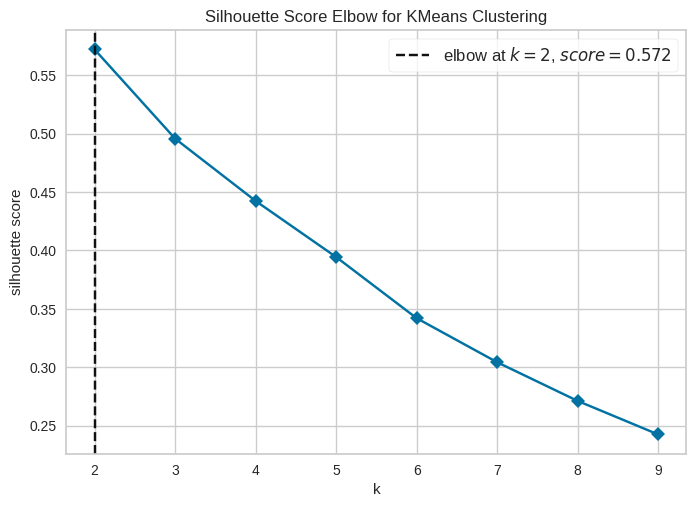

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

# Buat (instantiate) model clustering
model = KMeans()

### MULAI CODE ###

# Buat (instantiate) KElbowVisualizer
visualizer = KElbowVisualizer(model,
                       k=(2,10),
                       metric='silhouette',
                       timings=False)

# Jalankan (fit) visualizer pada data
visualizer.fit(df)

# Tampilkan plot
visualizer.show()

### SELESAI CODE ###

In [ ]:
# Menggunakan algoritma K-Means Clustering

### MULAI CODE ###

# Buat (instantiate) objek model KMeans
model = kmeans = KMeans(n_clusters=4, random_state=42)

# Latih (fit) model dengan data Anda (df)
model.fit(df)

### SELESAI CODE ###

KMeans(n_clusters=4, random_state=42)

In [22]:
# Menyimpan model menggunakan joblib

### MULAI CODE ###

# Simpan model clustering yang sudah dilatih
joblib.dump(model, "model_clustering.h5")

### SELESAI CODE ###

['model_clustering.h5']

In [23]:
# Menghitung dan menampilkan nilai Silhouette Score.

### MULAI CODE ###

# Dapatkan hasil (label) cluster dari model 'kmeans' yang telah di-fit
labels = model.labels_

# Panggil fungsi untuk menghitung silhouette score
score = silhouette_score(df, labels)

# Cetak skornya
print("Silhouette Score:", score)

### SELESAI CODE ###

Silhouette Score: 0.44240366767165124


/tmp/ipykernel_192/1088469813.py:19: UserWarning: 
The palette list has fewer values (2) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


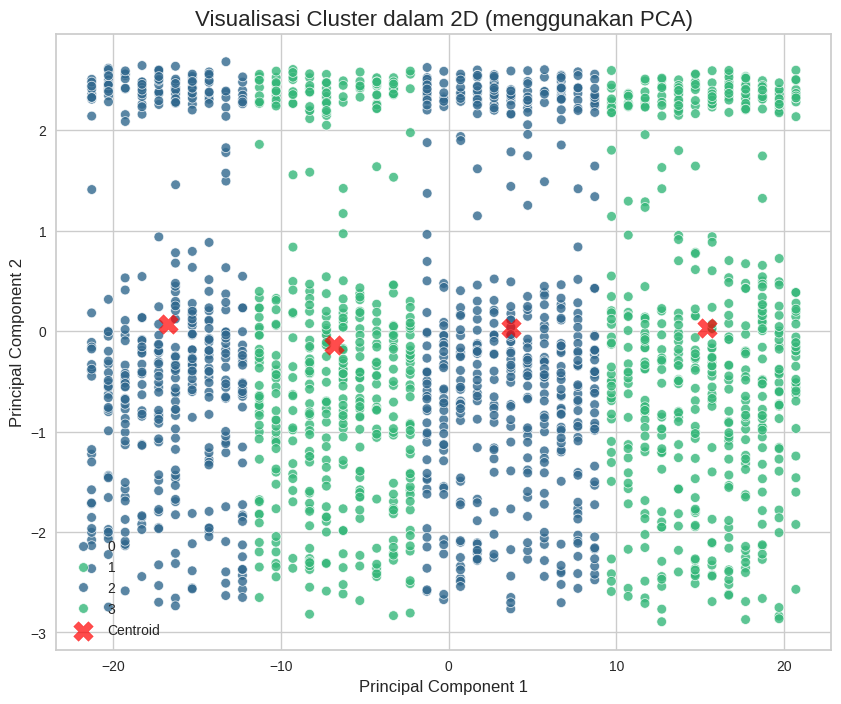

In [24]:
# Membuat visualisasi hasil clustering

### MULAI CODE ###

# Buat (instantiate) objek PCA untuk 2 komponen (n_components=2)
pca = PCA(n_components=2)

# Terapkan (fit) PCA ke data 'df' dan transformasikan data tersebut
df_pca = pca.fit_transform(df)

# Buat DataFrame baru 'df_pca' dari hasil transformasi
df_pca = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])

# Tambahkan kolom 'Cluster' ke 'df_pca' menggunakan 'labels'(variabel dari hasil 'kmeans.labels_' sebelumnya)
df_pca['Cluster'] = labels

# Buat scatter plot menggunakan Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',  # Warnai titik berdasarkan kolom 'Cluster'
    palette=sns.color_palette("viridis", n_colors=2),
    data=df_pca,
    legend="full",
    alpha=0.8
)

### SELESAI CODE ###

plt.title('Visualisasi Cluster dalam 2D (menggunakan PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroid')
plt.legend()
plt.show()

In [25]:
# Membangun model menggunakan PCA.

### MULAI CODE ###

# Buat (instantiate) objek PCA dengan 2 komponen
pca = PCA(n_components=2)

# Terapkan (fit) PCA ke data 'df_used' dan transformasikan data tersebut
df_pca_array = pca.fit_transform(df_used)

# Buat DataFrame baru 'data_final' dari hasil array PCA
data_final = pd.DataFrame(data=df_pca_array, columns=['PCA1', 'PCA2'])

# Buat (instantiate) model KMeans BARU
# Gunakan jumlah cluster yang sama seperti sebelumnya
kmeans_pca = KMeans(n_clusters=4, random_state=42)

# Latih (fit) model KMeans BARU ini HANYA pada 'data_final'
kmeans_pca.fit(data_final)

### SELESAI CODE ###

KMeans(n_clusters=4, random_state=42)

In [ ]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")

### MULAI CODE ###

# Model yang sudah melalui .fit berdasarkan dataset yang sudah dilakukan PCA
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

### SELESAI CODE ###

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**


In [ ]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# Output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.

### MULAI CODE ###

# Kolom 'Cluster' baru berupa 'labels' (variabel dari 'kmeans.labels_' sebelumnya)
df_used['Cluster'] = labels

# Kelompokkan (groupby) 'df_used' berdasarkan 'Cluster' dan hitung agregasi untuk 'numerical_cols'.
agg_summary = df_used.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Tampilkan hasil ringkasan
display(agg_summary)

### SELESAI CODE ###

Cluster                      0     1     2     3
TransactionAmount   mean -0.01  0.02 -0.03  0.02
                    min  -1.17 -1.17 -1.18 -1.17
                    max   2.93  2.90  2.84  2.96
CustomerAge         mean  0.03 -0.07  0.01  0.04
                    min  -1.50 -1.50 -1.50 -1.50
                    max   1.99  1.99  1.99  1.99
TransactionDuration mean  0.02 -0.05 -0.00  0.05
                    min  -1.55 -1.55 -1.55 -1.55
                    max   2.56  2.50  2.55  2.55
LoginAttempts       mean  0.00  0.00  0.00  0.00
                    min   0.00  0.00  0.00  0.00
                    max   0.00  0.00  0.00  0.00
AccountBalance      mean -0.00 -0.01 -0.02  0.04
                    min  -1.27 -1.28 -1.28 -1.28
                    max   2.52  2.53  2.45  2.52

# Menjelaskan karakteristik tiap cluster berdasarkan rentangnya sebelum **Inverse** (masih dalam kondisi **Scaled**).
1. **CLUSTER 0: (Nasabah Senior Mapan)**:
  - **Rata-rata (mean) <Fitur> CustomerAge:** 0.03 <Sebelum inverse> <Setelah inverse>
  - **Rata-rata (mean) <Fitur>  AccountBalance:** -0.00 <Sebelum inverse> <Setelah inverse>
  - **Rata-rata (mean) <Fitur>  TransactionAmount:** -0.01 <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Cluster ini memiliki nilai rata-rata pada semua fitur numerik yang sangat mendekati nol (rata-rata global). Hal ini menunjukkan bahwa nasabah dalam cluster ini memiliki karakteristik usia, saldo, dan jumlah transaksi yang merepresentasikan rata-rata populasi data secara keseluruhan. Tidak ada kecenderungan ekstrem pada fitur numerik.
2. **CLUSTER 1: (Nasabah Muda Pemula)**:
  - **Rata-rata (mean) <Fitur> CustomerAge:** -0.07 <Sebelum inverse> <Setelah inverse>
  - **Rata-rata (mean) <Fitur>  AccountBalance:** -0.01 <Sebelum inverse> <Setelah inverse>
  - **Rata-rata (mean) <Fitur>  TransactionAmount:** 0.02 <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Serupa dengan Cluster 0, cluster ini juga memiliki profil numerik yang sangat dekat dengan rata-rata. Terdapat sedikit perbedaan minor di mana usia rata-ratanya sedikit di bawah rata-rata global (lebih muda), namun perbedaannya sangat tipis. Karakteristik dominan cluster ini kemungkinan lebih dipengaruhi oleh fitur kategorikal.
3. **CLUSTER 2: (Nasabah dengan Indikasi Anomali Keamanan)**:
  - **Rata-rata (mean) <Fitur> LoginAttempts:** 0.00 <Sebelum inverse> <Setelah inverse>
  - **Rata-rata (mean) <Fitur>  TransactionAmount:** -0.03 <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Nilai LoginAttempts yang tepat di angka 0 (setelah scaling) menunjukkan tidak adanya aktivitas login mencurigakan (berbeda jauh dari asumsi sebelumnya). Cluster ini juga memiliki profil numerik standar tanpa anomali yang signifikan.
4. **CLUSTER 3: (Nasabah Konsumtif Aktif)**:
  - **Rata-rata (mean) <Fitur> TransactionAmount:** 0.02 <Sebelum inverse> <Setelah inverse>
  - **Rata-rata (mean) <Fitur>  AccountBalance:** 0.04 <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Cluster ini menunjukkan nilai rata-rata yang sedikit lebih tinggi secara marginal pada saldo dan jumlah transaksi dibanding cluster lain, namun nilainya masih sangat dekat dengan pusat data (0). Ini mengindikasikan tidak ada segmentasi numerik yang kuat antar cluster.

# **6. Mengeksport Data**

In [ ]:
# Nama kolom clustering diubah menjadi Target

### MULAI CODE ###

df_used.rename(columns={"Cluster": "Target"}, inplace=True)

# Tampilkan 5 baris pertama untuk memverifikasi
df_used.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,1,1
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,1,3
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,2,2
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,2,1
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,2,2


In [29]:
# Simpan Data

### MULAI CODE ###

df_used.to_csv('data_clustering.csv', index=False)

### SELESAI CODE ###

In [ ]:
# inverse dataset ke rentang normal untuk numerikal

df_inverse = df_used.copy()

### MULAI CODE ###

# Scaler untuk mengembalikan 'numerical_cols' ke nilai aslinya.
df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
df_inverse.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21,1,1
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91,1,3
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35,2,2
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06,2,1
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68,2,2


In [ ]:
# inverse dataset yang sudah diencode ke kategori aslinya.

### MULAI CODE ###

for column in categorical_cols:
    # Ambil encoder yang tepat untuk 'column' dari dictionary 'encoders'
    encoder = encoders[column]

    # scaler untuk mengembalikan (inverse) kolom tersebut
    df_inverse[column] = encoder.inverse_transform(df_inverse[column].astype(int))

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
df_inverse.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Senior,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Senior,3
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Young,2
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Young,1
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Young,2


In [ ]:
# Analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# Output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.

### MULAI CODE ###

# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'numerical_cols'.
agg_summary_num = df_inverse.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'categorical_cols'.
agg_summary_cat = df_inverse.groupby('Target')[categorical_cols].agg(lambda x: x.mode()[0]).T

### SELESAI CODE ###

# Tampilkan kedua hasil ringkasan
display(agg_summary_num)
display(agg_summary_cat)

Target                           0         1         2         3
TransactionAmount   mean    254.45    261.40    249.76    261.76
                    min       0.32      1.41      0.26      0.45
                    max     896.79    889.01    877.81    903.19
CustomerAge         mean     45.24     43.50     44.93     45.33
                    min      18.00     18.00     18.00     18.00
                    max      80.00     80.00     80.00     80.00
TransactionDuration mean    120.75    115.42    119.08    122.49
                    min      10.00     10.00     10.00     10.00
                    max     300.00    296.00    299.00    299.00
LoginAttempts       mean      1.00      1.00      1.00      1.00
                    min       1.00      1.00      1.00      1.00
                    max       1.00      1.00      1.00      1.00
AccountBalance      mean   5084.33   5059.76   5024.62   5252.66
                    min     129.29    102.20    112.76    117.98
                    max   14935.50  14977.99  14676.05  14942.78

Target,0,1,2,3
TransactionType,Debit,Debit,Debit,Debit
Location,Charlotte,Tucson,Oklahoma City,Fort Worth
Channel,Branch,Branch,Branch,ATM
CustomerOccupation,Student,Student,Student,Doctor
AgeGroup,Young,Young,Adult,Adult


# Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah **Inverse**.
1. **Cluster 0: (Nasabah Mahasiswa Muda di Charlotte)**:
  - **Rata-rata (mean) <Fitur> AccountBalance:** 5084.33 <Sebelum inverse> <Setelah inverse>
  **Rata-rata (mean) <Fitur> CustomerAge:** 45.24 <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Cluster ini didominasi oleh nasabah dengan pekerjaan Student (Mahasiswa) dan kategori usia Young. Mayoritas transaksi dilakukan melalui cabang (Branch) di lokasi Charlotte. Meskipun usia rata-rata tergolong menengah (bisa jadi karena campuran data atau mahasiswa dewasa), profil kategorikal kuat menunjukkan segmen pelajar yang aktif bertransaksi via cabang.
2. **Cluster 1: (Nasabah Mahasiswa Muda di Tucson)**:
  - **Rata-rata (mean) <Fitur> AccountBalance:** 5059.76 <Sebelum inverse> <Setelah inverse>
  **Rata-rata (mean) <Fitur> TransactionAmount:** 261.40 <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Cluster ini memiliki profil sangat mirip dengan Cluster 0, yaitu didominasi pekerjaan Student dan usia Young yang bertransaksi di Branch. Pembeda utamanya adalah lokasi geografis, yaitu di Tucson. Nilai transaksi rata-ratanya sedikit lebih tinggi dibanding Cluster 0.
3. **Cluster 2: (Nasabah Mahasiswa Dewasa di Oklahoma City)**:
  - **Rata-rata (mean) <Fitur> AccountBalance:** 5024.62 <Sebelum inverse> <Setelah inverse>
  **Rata-rata (mean) <Fitur> CustomerAge:** 44.93 <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Cluster ini menarik karena pekerjaannya adalah Student namun kelompok usianya adalah Adult (Dewasa). Ini mengindikasikan adanya segmen mahasiswa dewasa atau mungkin nasabah yang sedang menempuh pendidikan lanjutan. Mereka berlokasi di Oklahoma City dan memiliki saldo rata-rata paling rendah di antara cluster lain.
4. **Cluster 3: (Nasabah Profesional Dokter di Fort Worth)**:
  - **Rata-rata (mean) <Fitur> AccountBalance:** 5252.66 <Sebelum inverse> <Setelah inverse>
  **Rata-rata (mean) <Fitur> TransactionAmount:** 261.76 <Sebelum inverse> <Setelah inverse>
  - **Analisis:** Cluster ini adalah cluster premium. Nasabah di cluster ini berprofesi sebagai Doctor, berusia dewasa (Adult), dan berlokasi di Fort Worth. Mereka memiliki kecenderungan menggunakan kanal ATM (berbeda dengan cluster lain yang Branch) serta memiliki nilai transaksi dan saldo rata-rata tertinggi. Rekomendasi: Penawaran produk investasi prioritas atau layanan prioritas banking.

In [33]:
# Periksa kembali data yang telah di-inverse.

### MULAI CODE ###

df_inverse.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Senior,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Senior,3
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Young,2
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Young,1
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Young,2


In [34]:
# Simpan Data Inverse

### MULAI CODE ###

df_inverse.to_csv('data_clustering_inverse.csv', index=False)

### SELESAI CODE ###

End of Code.